         fit_folder participant sampler  train_error  \
0     Hybrid_SC_fit      QP0100  CMA-ES     0.010779   
1     Hybrid_SC_fit      QP0101  CMA-ES     0.035908   
2     Hybrid_SC_fit      QP0103  CMA-ES     0.016082   
3     Hybrid_SC_fit      QP0121  CMA-ES     0.012828   
4     Hybrid_SC_fit       QP062  CMA-ES     0.004824   
..              ...         ...     ...          ...   
59  Hybrid_new2_fit      QP0121     TPE     0.010438   
60  Hybrid_new2_fit       QP062     TPE     0.002867   
61  Hybrid_new2_fit       QP063     TPE     0.003706   
62  Hybrid_new2_fit       QP070     TPE     0.011458   
63  Hybrid_new2_fit       QP071     TPE     0.005743   

                                    file  
0   results_pid_QP0100_seed_1_CMA-ES.pkl  
1   results_pid_QP0101_seed_1_CMA-ES.pkl  
2   results_pid_QP0103_seed_1_CMA-ES.pkl  
3   results_pid_QP0121_seed_1_CMA-ES.pkl  
4    results_pid_QP062_seed_1_CMA-ES.pkl  
..                                   ...  
59     results_pid_QP0121_

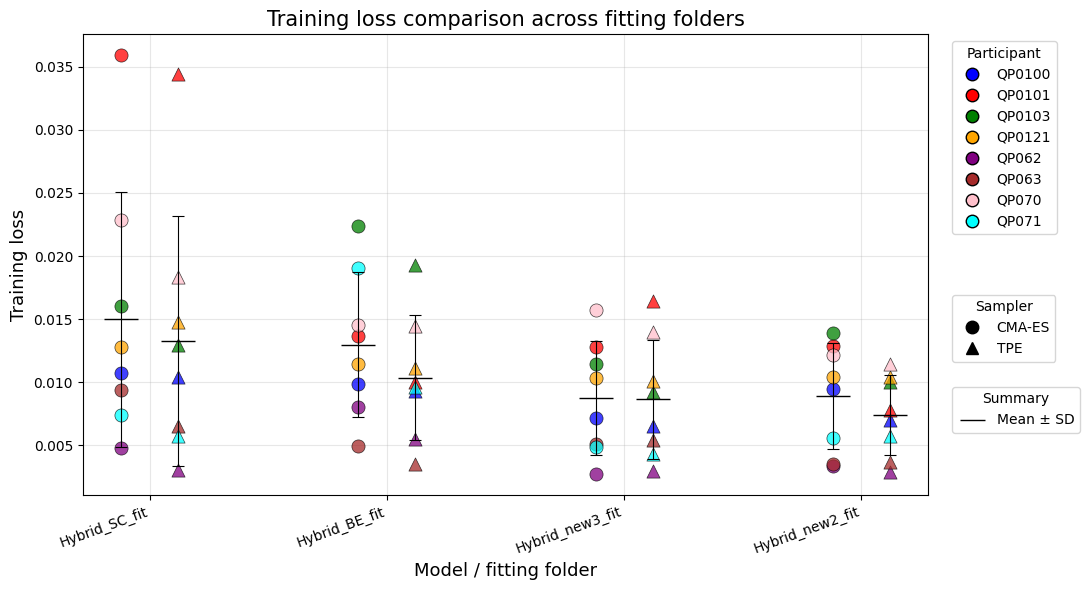

Saved plot: D:\sc_modelling-amir-2025\training_loss_comparison\training_loss_comparison_with_mean_variance1.png


In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =========================
# Paths and settings
# =========================
root_dir = r"D:\sc_modelling-amir-2025"

fit_folders = [
    "Hybrid_SC_fit",
    "Hybrid_BE_fit",
    "Hybrid_new3_fit",
    "Hybrid_new2_fit",
]

participants = ['QP0100', 'QP0101', 'QP0103', 'QP0121',
                'QP062', 'QP063', 'QP070', 'QP071']

samplers = ['CMA-ES', 'TPE']

output_dir = os.path.join(root_dir, "training_loss_comparison")
os.makedirs(output_dir, exist_ok=True)

participant_colors = {
    'QP0100': 'blue',
    'QP0101': 'red',
    'QP0103': 'green',
    'QP0121': 'orange',
    'QP062': 'purple',
    'QP063': 'brown',
    'QP070': 'pink',
    'QP071': 'cyan',
}

sampler_markers = {
    "CMA-ES": "o",
    "TPE": "^",
}

# =========================
# Read training losses
# =========================
rows = []

for fit_folder in fit_folders:
    base_dir = os.path.join(root_dir, fit_folder, "Mouse", "results")

    for sampler in samplers:
        for participant in participants:
            folder = os.path.join(base_dir, sampler, participant)

            if not os.path.isdir(folder):
                print(f"Folder not found: {folder}")
                continue

            for fname in os.listdir(folder):
                if not fname.endswith(".pkl"):
                    continue

                fpath = os.path.join(folder, fname)

                try:
                    with open(fpath, "rb") as f:
                        data = pickle.load(f)
                except Exception as e:
                    print(f"Could not read {fpath}: {e}")
                    continue

                rows.append({
                    "fit_folder": fit_folder,
                    "participant": participant,
                    "sampler": sampler,
                    "train_error": data.get("best_error", np.nan),
                    "file": fname
                })

df = pd.DataFrame(rows)

print(df)

# =========================
# Save CSV
# =========================
csv_path = os.path.join(output_dir, "training_losses_all_folders.csv")
df.to_csv(csv_path, index=False)
print(f"Saved CSV: {csv_path}")

# =========================
# Summary statistics
# =========================
summary = (
    df
    .dropna(subset=["train_error"])
    .groupby(["fit_folder", "sampler"])["train_error"]
    .agg(["mean", "var", "std", "count"])
    .reset_index()
)

summary_csv_path = os.path.join(output_dir, "training_loss_mean_variance.csv")
summary.to_csv(summary_csv_path, index=False)
print(f"Saved summary CSV: {summary_csv_path}")

print(summary)

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(11, 6))

x_positions = {folder: i for i, folder in enumerate(fit_folders)}

# Individual animals
for _, row in df.iterrows():

    if pd.isna(row["train_error"]):
        continue

    x = x_positions[row["fit_folder"]]
    offset = -0.12 if row["sampler"] == "CMA-ES" else 0.12

    ax.scatter(
        x + offset,
        row["train_error"],
        s=90,
        alpha=0.75,
        color=participant_colors[row["participant"]],
        marker=sampler_markers[row["sampler"]],
        edgecolors='black',
        linewidths=0.5,
        zorder=3
    )

# Mean and variance/std for each folder and sampler
for _, row in summary.iterrows():

    x = x_positions[row["fit_folder"]]
    offset = -0.12 if row["sampler"] == "CMA-ES" else 0.12
    x_plot = x + offset

    mean = row["mean"]
    std = row["std"]

    ax.errorbar(
        x_plot,
        mean,
        yerr=std,
        fmt='_',
        color='black',
        markersize=24,
        elinewidth=0.8,
        capsize=4,
        capthick=0.8,
        zorder=10
    )

# =========================
# Axis styling
# =========================
ax.set_xticks(range(len(fit_folders)))
ax.set_xticklabels(fit_folders, rotation=20, ha="right")

ax.set_ylabel("Training loss", fontsize=13)
ax.set_xlabel("Model / fitting folder", fontsize=13)
ax.set_title("Training loss comparison across fitting folders", fontsize=15)

ax.grid(True, alpha=0.3)

# =========================
# Legends
# =========================
participant_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=participant_colors[p],
        markeredgecolor='black',
        markersize=9,
        label=p
    )
    for p in participants
]

sampler_handles = [
    Line2D(
        [0], [0],
        marker=sampler_markers[s],
        color='black',
        linestyle='None',
        markersize=9,
        label=s
    )
    for s in samplers
]

mean_handle = Line2D(
    [0], [0],
    marker='_',
    color='black',
    linestyle='None',
    markersize=18,
    label='Mean ± SD'
)

legend1 = ax.legend(
    handles=participant_handles,
    title="Participant",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
ax.add_artist(legend1)

legend2 = ax.legend(
    handles=sampler_handles,
    title="Sampler",
    bbox_to_anchor=(1.02, 0.45),
    loc='upper left'
)
ax.add_artist(legend2)

ax.legend(
    handles=[mean_handle],
    title="Summary",
    bbox_to_anchor=(1.02, 0.25),
    loc='upper left'
)

# =========================
# Save figure
# =========================
plt.tight_layout()

plot_path = os.path.join(output_dir, "training_loss_comparison_with_mean_variance1.png")

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved plot: {plot_path}")

         fit_folder participant sampler  train_error  \
0     Hybrid_BE_fit      QP0100  CMA-ES     0.009843   
1     Hybrid_BE_fit      QP0101  CMA-ES     0.013661   
2     Hybrid_BE_fit      QP0103  CMA-ES     0.022364   
3     Hybrid_BE_fit      QP0121  CMA-ES     0.011460   
4     Hybrid_BE_fit       QP062  CMA-ES     0.008026   
..              ...         ...     ...          ...   
91  Hybrid_new2_fit      QP0121     TPE     0.010438   
92  Hybrid_new2_fit       QP062     TPE     0.002867   
93  Hybrid_new2_fit       QP063     TPE     0.003706   
94  Hybrid_new2_fit       QP070     TPE     0.011458   
95  Hybrid_new2_fit       QP071     TPE     0.005743   

                                    file  
0   results_pid_QP0100_seed_1_CMA-ES.pkl  
1   results_pid_QP0101_seed_1_CMA-ES.pkl  
2   results_pid_QP0103_seed_1_CMA-ES.pkl  
3   results_pid_QP0121_seed_1_CMA-ES.pkl  
4    results_pid_QP062_seed_1_CMA-ES.pkl  
..                                   ...  
91     results_pid_QP0121_

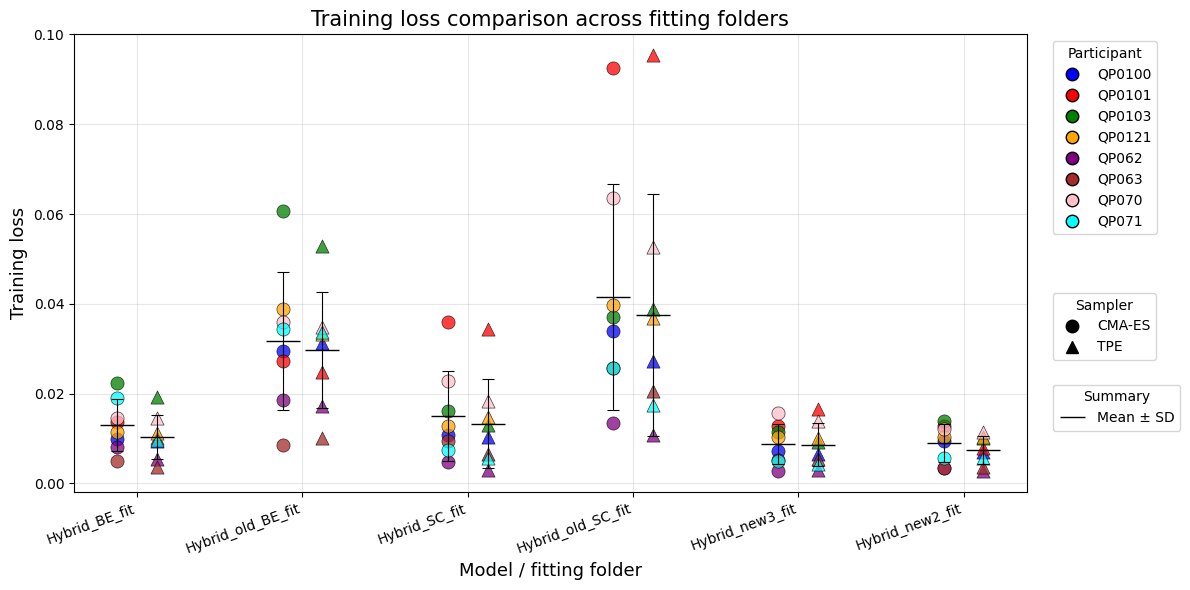

Saved plot: D:\sc_modelling-amir-2025\training_loss_comparison\training_loss_comparison_with_mean_variance.png


In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =========================
# Paths and settings
# =========================
root_dir = r"D:\sc_modelling-amir-2025"

fit_folders = [
    "Hybrid_BE_fit",
    "Hybrid_old_BE_fit",
    "Hybrid_SC_fit",
    "Hybrid_old_SC_fit",
    "Hybrid_new3_fit",
    "Hybrid_new2_fit",
]

participants = [
    'QP0100', 'QP0101', 'QP0103', 'QP0121',
    'QP062', 'QP063', 'QP070', 'QP071'
]

samplers = ['CMA-ES', 'TPE']

output_dir = os.path.join(root_dir, "training_loss_comparison")
os.makedirs(output_dir, exist_ok=True)

participant_colors = {
    'QP0100': 'blue',
    'QP0101': 'red',
    'QP0103': 'green',
    'QP0121': 'orange',
    'QP062': 'purple',
    'QP063': 'brown',
    'QP070': 'pink',
    'QP071': 'cyan',
}

sampler_markers = {
    "CMA-ES": "o",
    "TPE": "^",
}

# =========================
# Read training losses
# =========================
rows = []

for fit_folder in fit_folders:

    base_dir = os.path.join(root_dir, fit_folder, "Mouse", "results")

    for sampler in samplers:
        for participant in participants:

            folder = os.path.join(base_dir, sampler, participant)

            if not os.path.isdir(folder):
                print(f"Folder not found: {folder}")
                continue

            for fname in os.listdir(folder):

                if not fname.endswith(".pkl"):
                    continue

                fpath = os.path.join(folder, fname)

                try:
                    with open(fpath, "rb") as f:
                        data = pickle.load(f)

                except Exception as e:
                    print(f"Could not read {fpath}: {e}")
                    continue

                rows.append({
                    "fit_folder": fit_folder,
                    "participant": participant,
                    "sampler": sampler,
                    "train_error": data.get("best_error", np.nan),
                    "file": fname
                })

df = pd.DataFrame(rows)

print(df)

# =========================
# Save CSV
# =========================
csv_path = os.path.join(output_dir, "training_losses_all_folders.csv")
df.to_csv(csv_path, index=False)
print(f"Saved CSV: {csv_path}")

# =========================
# Summary statistics
# =========================
summary = (
    df
    .dropna(subset=["train_error"])
    .groupby(["fit_folder", "sampler"])["train_error"]
    .agg(["mean", "var", "std", "count"])
    .reset_index()
)

summary_csv_path = os.path.join(
    output_dir,
    "training_loss_mean_variance.csv"
)
summary.to_csv(summary_csv_path, index=False)

print(f"Saved summary CSV: {summary_csv_path}")
print(summary)

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(12, 6))

x_positions = {folder: i for i, folder in enumerate(fit_folders)}

# -------------------------
# Individual animals
# -------------------------
for _, row in df.iterrows():

    if pd.isna(row["train_error"]):
        continue

    x = x_positions[row["fit_folder"]]
    offset = -0.12 if row["sampler"] == "CMA-ES" else 0.12

    ax.scatter(
        x + offset,
        row["train_error"],
        s=90,
        alpha=0.75,
        color=participant_colors[row["participant"]],
        marker=sampler_markers[row["sampler"]],
        edgecolors='black',
        linewidths=0.5,
        zorder=3
    )

# -------------------------
# Mean ± SD
# -------------------------
for _, row in summary.iterrows():

    x = x_positions[row["fit_folder"]]
    offset = -0.12 if row["sampler"] == "CMA-ES" else 0.12
    x_plot = x + offset

    mean = row["mean"]
    std = row["std"]

    ax.errorbar(
        x_plot,
        mean,
        yerr=std,
        fmt='_',
        color='black',
        markersize=24,
        elinewidth=0.8,
        capsize=4,
        capthick=0.8,
        zorder=10
    )

# =========================
# Axis styling
# =========================
ax.set_xticks(range(len(fit_folders)))
ax.set_xticklabels(fit_folders, rotation=20, ha="right")

ax.set_ylabel("Training loss", fontsize=13)
ax.set_xlabel("Model / fitting folder", fontsize=13)
ax.set_title(
    "Training loss comparison across fitting folders",
    fontsize=15
)

ax.grid(True, alpha=0.3)

# =========================
# Legends
# =========================
participant_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=participant_colors[p],
        markeredgecolor='black',
        markersize=9,
        label=p
    )
    for p in participants
]

sampler_handles = [
    Line2D(
        [0], [0],
        marker=sampler_markers[s],
        color='black',
        linestyle='None',
        markersize=9,
        label=s
    )
    for s in samplers
]

mean_handle = Line2D(
    [0], [0],
    marker='_',
    color='black',
    linestyle='None',
    markersize=18,
    label='Mean ± SD'
)

legend1 = ax.legend(
    handles=participant_handles,
    title="Participant",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
ax.add_artist(legend1)

legend2 = ax.legend(
    handles=sampler_handles,
    title="Sampler",
    bbox_to_anchor=(1.02, 0.45),
    loc='upper left'
)
ax.add_artist(legend2)

ax.legend(
    handles=[mean_handle],
    title="Summary",
    bbox_to_anchor=(1.02, 0.25),
    loc='upper left'
)

# =========================
# Save figure
# =========================
plt.tight_layout()

plot_path = os.path.join(
    output_dir,
    "training_loss_comparison_with_mean_variance.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved plot: {plot_path}")

          fit_folder participant sampler  train_error  \
0      Hybrid_BE_fit     6363339  CMA-ES     0.015301   
1      Hybrid_BE_fit     6363334  CMA-ES     0.019707   
2      Hybrid_BE_fit     6363353  CMA-ES     0.007039   
3      Hybrid_BE_fit     6363338  CMA-ES     0.052569   
4      Hybrid_BE_fit     6363346  CMA-ES     0.026719   
..               ...         ...     ...          ...   
331  Hybrid_new2_fit     6357501     TPE     0.013837   
332  Hybrid_new2_fit     6357497     TPE     0.009531   
333  Hybrid_new2_fit     6357556     TPE     0.010854   
334  Hybrid_new2_fit     6357698     TPE     0.020830   
335  Hybrid_new2_fit     6357829     TPE     0.006217   

                                      file  
0    results_pid_6363339_seed_1_CMA-ES.pkl  
1    results_pid_6363334_seed_1_CMA-ES.pkl  
2    results_pid_6363353_seed_1_CMA-ES.pkl  
3    results_pid_6363338_seed_1_CMA-ES.pkl  
4    results_pid_6363346_seed_1_CMA-ES.pkl  
..                                     ...  


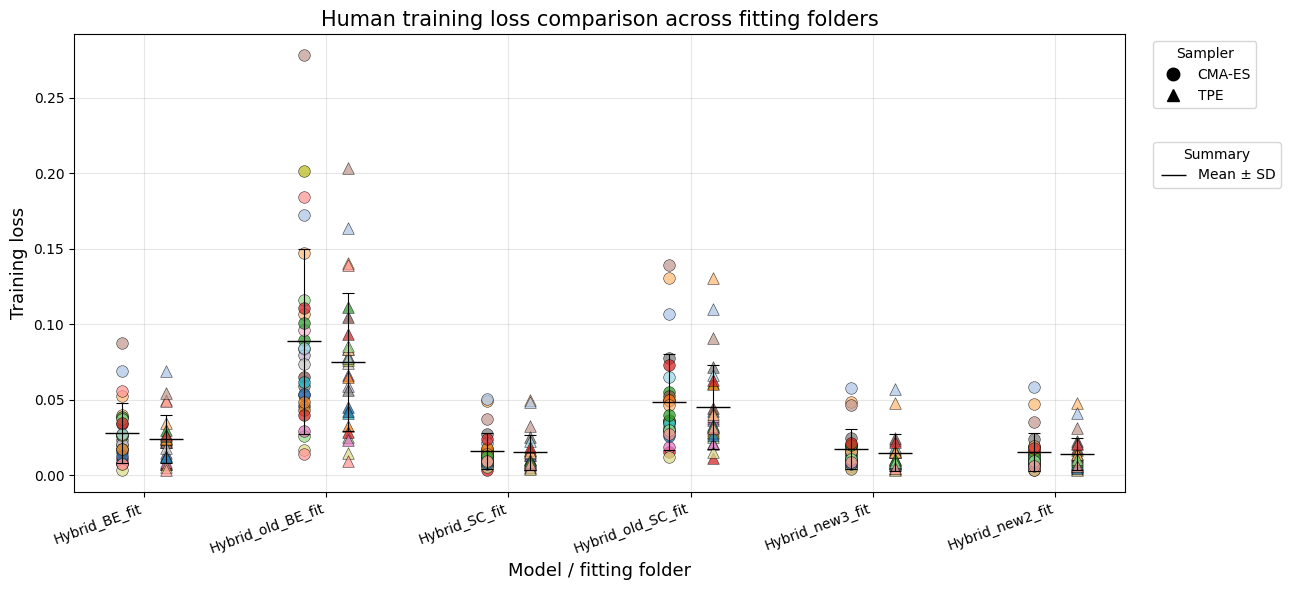

Saved plot: D:\sc_modelling-amir-2025\training_loss_comparison_human\training_loss_comparison_human_with_mean_variance1.png


In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =========================
# Paths and settings
# =========================
root_dir = r"D:\sc_modelling-amir-2025"

fit_folders = [
    "Hybrid_BE_fit",
    "Hybrid_old_BE_fit",
    "Hybrid_SC_fit",
    "Hybrid_old_SC_fit",
    "Hybrid_new3_fit",
    "Hybrid_new2_fit",
]

participants = [
    '6363339', '6363334', '6363353', '6363338', '6363346', '6363343',
    '6363329', '6363354', '6363347', '6363328', '6363330', '6363341',
    '6363407', '6363430', '6363368', '6363349', '6363364', '6269773',
    '6269770', '6269757', '6269881', '6357507', '6357495', '6357501',
    '6357497', '6357556', '6357698', '6357829'
]

samplers = ['CMA-ES', 'TPE']

output_dir = os.path.join(root_dir, "training_loss_comparison_human")
os.makedirs(output_dir, exist_ok=True)

cmap = plt.get_cmap("tab20")
participant_colors = {
    participant: cmap(i % 20)
    for i, participant in enumerate(participants)
}

sampler_markers = {
    "CMA-ES": "o",
    "TPE": "^",
}

# =========================
# Read training losses
# =========================
rows = []

for fit_folder in fit_folders:
    base_dir = os.path.join(root_dir, fit_folder, "Human", "results")

    for sampler in samplers:
        for participant in participants:
            folder = os.path.join(base_dir, sampler, participant)

            if not os.path.isdir(folder):
                print(f"Folder not found: {folder}")
                continue

            for fname in os.listdir(folder):
                if not fname.endswith(".pkl"):
                    continue

                fpath = os.path.join(folder, fname)

                try:
                    with open(fpath, "rb") as f:
                        data = pickle.load(f)
                except Exception as e:
                    print(f"Could not read {fpath}: {e}")
                    continue

                rows.append({
                    "fit_folder": fit_folder,
                    "participant": participant,
                    "sampler": sampler,
                    "train_error": data.get("best_error", np.nan),
                    "file": fname
                })

df = pd.DataFrame(rows)

print(df)

# =========================
# Save CSV
# =========================
csv_path = os.path.join(output_dir, "training_losses_all_folders_human.csv")
df.to_csv(csv_path, index=False)
print(f"Saved CSV: {csv_path}")

# =========================
# Summary statistics
# =========================
summary = (
    df
    .dropna(subset=["train_error"])
    .groupby(["fit_folder", "sampler"])["train_error"]
    .agg(["mean", "var", "std", "count"])
    .reset_index()
)

summary_csv_path = os.path.join(output_dir, "training_loss_mean_variance_human.csv")
summary.to_csv(summary_csv_path, index=False)
print(f"Saved summary CSV: {summary_csv_path}")

print(summary)

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(13, 6))

x_positions = {folder: i for i, folder in enumerate(fit_folders)}

# Individual human subjects
for _, row in df.iterrows():

    if pd.isna(row["train_error"]):
        continue

    x = x_positions[row["fit_folder"]]
    offset = -0.12 if row["sampler"] == "CMA-ES" else 0.12

    ax.scatter(
        x + offset,
        row["train_error"],
        s=70,
        alpha=0.75,
        color=participant_colors[row["participant"]],
        marker=sampler_markers[row["sampler"]],
        edgecolors="black",
        linewidths=0.4,
        zorder=3
    )

# Mean ± SD for each folder and sampler
for _, row in summary.iterrows():

    x = x_positions[row["fit_folder"]]
    offset = -0.12 if row["sampler"] == "CMA-ES" else 0.12

    ax.errorbar(
        x + offset,
        row["mean"],
        yerr=row["std"],
        fmt="_",
        color="black",
        markersize=24,
        elinewidth=0.8,
        capsize=4,
        capthick=0.8,
        zorder=10
    )

# =========================
# Axis styling
# =========================
ax.set_xticks(range(len(fit_folders)))
ax.set_xticklabels(fit_folders, rotation=20, ha="right")

ax.set_ylabel("Training loss", fontsize=13)
ax.set_xlabel("Model / fitting folder", fontsize=13)
ax.set_title("Human training loss comparison across fitting folders", fontsize=15)

ax.grid(True, alpha=0.3)

# =========================
# Legends
# =========================
sampler_handles = [
    Line2D(
        [0], [0],
        marker=sampler_markers[s],
        color="black",
        linestyle="None",
        markersize=9,
        label=s
    )
    for s in samplers
]

mean_handle = Line2D(
    [0], [0],
    marker="_",
    color="black",
    linestyle="None",
    markersize=18,
    label="Mean ± SD"
)

legend1 = ax.legend(
    handles=sampler_handles,
    title="Sampler",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
ax.add_artist(legend1)

ax.legend(
    handles=[mean_handle],
    title="Summary",
    bbox_to_anchor=(1.02, 0.78),
    loc="upper left"
)

# =========================
# Save figure
# =========================
plt.tight_layout()

plot_path = os.path.join(
    output_dir,
    "training_loss_comparison_human_with_mean_variance1.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved plot: {plot_path}")

          fit_folder participant sampler  train_error  \
0      Hybrid_BE_fit     6363339  CMA-ES     0.015301   
1      Hybrid_BE_fit     6363334  CMA-ES     0.019707   
2      Hybrid_BE_fit     6363353  CMA-ES     0.007039   
3      Hybrid_BE_fit     6363338  CMA-ES     0.052569   
4      Hybrid_BE_fit     6363346  CMA-ES     0.026719   
..               ...         ...     ...          ...   
219  Hybrid_new2_fit     6357501     TPE     0.013837   
220  Hybrid_new2_fit     6357497     TPE     0.009531   
221  Hybrid_new2_fit     6357556     TPE     0.010854   
222  Hybrid_new2_fit     6357698     TPE     0.020830   
223  Hybrid_new2_fit     6357829     TPE     0.006217   

                                      file  
0    results_pid_6363339_seed_1_CMA-ES.pkl  
1    results_pid_6363334_seed_1_CMA-ES.pkl  
2    results_pid_6363353_seed_1_CMA-ES.pkl  
3    results_pid_6363338_seed_1_CMA-ES.pkl  
4    results_pid_6363346_seed_1_CMA-ES.pkl  
..                                     ...  


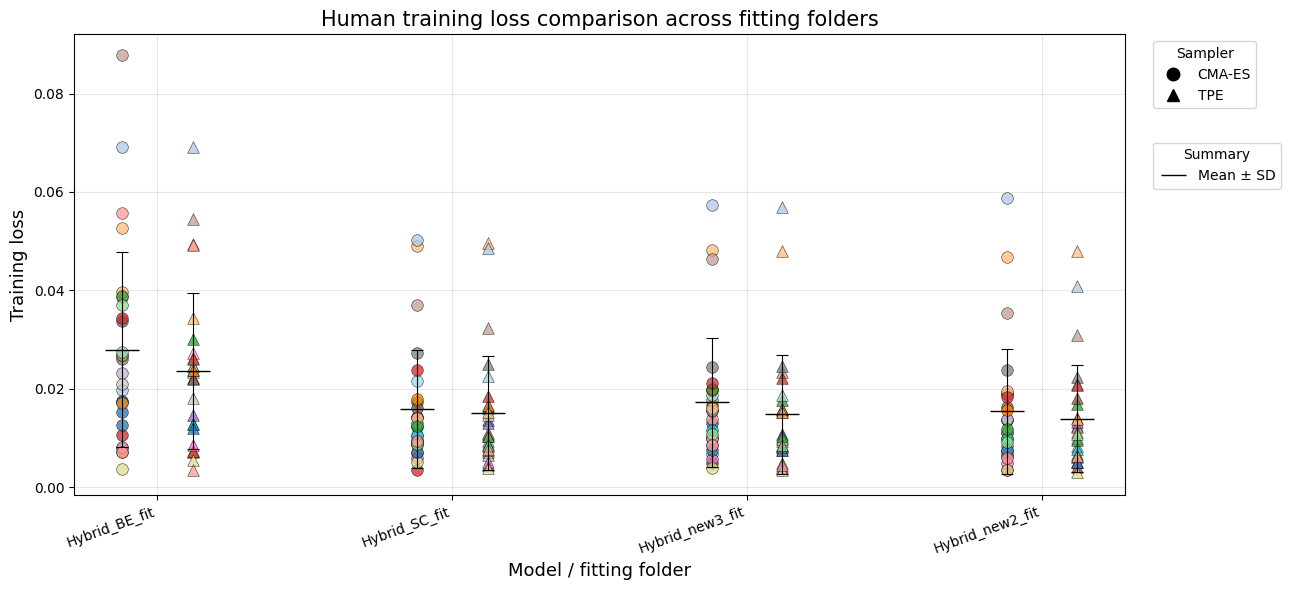

Saved plot: D:\sc_modelling-amir-2025\training_loss_comparison_human\training_loss_comparison_human_with_mean_variance.png


: 

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =========================
# Paths and settings
# =========================
root_dir = r"D:\sc_modelling-amir-2025"

fit_folders = [
    "Hybrid_BE_fit",
    "Hybrid_SC_fit",
    "Hybrid_new3_fit",
    "Hybrid_new2_fit",
]

participants = [
    '6363339', '6363334', '6363353', '6363338', '6363346', '6363343',
    '6363329', '6363354', '6363347', '6363328', '6363330', '6363341',
    '6363407', '6363430', '6363368', '6363349', '6363364', '6269773',
    '6269770', '6269757', '6269881', '6357507', '6357495', '6357501',
    '6357497', '6357556', '6357698', '6357829'
]

samplers = ['CMA-ES', 'TPE']

output_dir = os.path.join(root_dir, "training_loss_comparison_human")
os.makedirs(output_dir, exist_ok=True)

cmap = plt.get_cmap("tab20")
participant_colors = {
    participant: cmap(i % 20)
    for i, participant in enumerate(participants)
}

sampler_markers = {
    "CMA-ES": "o",
    "TPE": "^",
}

# =========================
# Read training losses
# =========================
rows = []

for fit_folder in fit_folders:
    base_dir = os.path.join(root_dir, fit_folder, "Human", "results")

    for sampler in samplers:
        for participant in participants:
            folder = os.path.join(base_dir, sampler, participant)

            if not os.path.isdir(folder):
                print(f"Folder not found: {folder}")
                continue

            for fname in os.listdir(folder):
                if not fname.endswith(".pkl"):
                    continue

                fpath = os.path.join(folder, fname)

                try:
                    with open(fpath, "rb") as f:
                        data = pickle.load(f)
                except Exception as e:
                    print(f"Could not read {fpath}: {e}")
                    continue

                rows.append({
                    "fit_folder": fit_folder,
                    "participant": participant,
                    "sampler": sampler,
                    "train_error": data.get("best_error", np.nan),
                    "file": fname
                })

df = pd.DataFrame(rows)

print(df)

# =========================
# Save CSV
# =========================
csv_path = os.path.join(output_dir, "training_losses_all_folders_human.csv")
df.to_csv(csv_path, index=False)
print(f"Saved CSV: {csv_path}")

# =========================
# Summary statistics
# =========================
summary = (
    df
    .dropna(subset=["train_error"])
    .groupby(["fit_folder", "sampler"])["train_error"]
    .agg(["mean", "var", "std", "count"])
    .reset_index()
)

summary_csv_path = os.path.join(output_dir, "training_loss_mean_variance_human.csv")
summary.to_csv(summary_csv_path, index=False)
print(f"Saved summary CSV: {summary_csv_path}")

print(summary)

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(13, 6))

x_positions = {folder: i for i, folder in enumerate(fit_folders)}

# Individual human subjects
for _, row in df.iterrows():

    if pd.isna(row["train_error"]):
        continue

    x = x_positions[row["fit_folder"]]
    offset = -0.12 if row["sampler"] == "CMA-ES" else 0.12

    ax.scatter(
        x + offset,
        row["train_error"],
        s=70,
        alpha=0.75,
        color=participant_colors[row["participant"]],
        marker=sampler_markers[row["sampler"]],
        edgecolors="black",
        linewidths=0.4,
        zorder=3
    )

# Mean ± SD for each folder and sampler
for _, row in summary.iterrows():

    x = x_positions[row["fit_folder"]]
    offset = -0.12 if row["sampler"] == "CMA-ES" else 0.12

    ax.errorbar(
        x + offset,
        row["mean"],
        yerr=row["std"],
        fmt="_",
        color="black",
        markersize=24,
        elinewidth=0.8,
        capsize=4,
        capthick=0.8,
        zorder=10
    )

# =========================
# Axis styling
# =========================
ax.set_xticks(range(len(fit_folders)))
ax.set_xticklabels(fit_folders, rotation=20, ha="right")

ax.set_ylabel("Training loss", fontsize=13)
ax.set_xlabel("Model / fitting folder", fontsize=13)
ax.set_title("Human training loss comparison across fitting folders", fontsize=15)

ax.grid(True, alpha=0.3)

# =========================
# Legends
# =========================
sampler_handles = [
    Line2D(
        [0], [0],
        marker=sampler_markers[s],
        color="black",
        linestyle="None",
        markersize=9,
        label=s
    )
    for s in samplers
]

mean_handle = Line2D(
    [0], [0],
    marker="_",
    color="black",
    linestyle="None",
    markersize=18,
    label="Mean ± SD"
)

legend1 = ax.legend(
    handles=sampler_handles,
    title="Sampler",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
ax.add_artist(legend1)

ax.legend(
    handles=[mean_handle],
    title="Summary",
    bbox_to_anchor=(1.02, 0.78),
    loc="upper left"
)

# =========================
# Save figure
# =========================
plt.tight_layout()

plot_path = os.path.join(
    output_dir,
    "training_loss_comparison_human_with_mean_variance.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved plot: {plot_path}")

In [6]:
import pandas as pd
from scipy.stats import ranksums
from itertools import combinations

human_df = pd.read_csv(
    r"D:\sc_modelling-amir-2025\training_loss_comparison_human\training_losses_all_folders_human.csv"
)

mouse_df = pd.read_csv(
    r"D:\sc_modelling-amir-2025\training_loss_comparison\training_losses_all_folders.csv"
)

print("Human columns:", human_df.columns.tolist())
print("Mouse columns:", mouse_df.columns.tolist())

folder_col = "fit_folder"
loss_col = "train_error"


def pairwise_ranksums(df):
    folders = sorted(df[folder_col].dropna().unique())
    results = []

    for f1, f2 in combinations(folders, 2):
        x = df[df[folder_col] == f1][loss_col].dropna()
        y = df[df[folder_col] == f2][loss_col].dropna()

        statistic, pvalue = ranksums(x, y)

        results.append({
            "Folder 1": f1,
            "Folder 2": f2,
            "n1": len(x),
            "n2": len(y),
            "mean 1": x.mean(),
            "mean 2": y.mean(),
            "Rank-sum statistic": statistic,
            "p-value": pvalue
        })

    return pd.DataFrame(results)


human_results = pairwise_ranksums(human_df)
mouse_results = pairwise_ranksums(mouse_df)

print("\nHuman:")
display(human_results.sort_values("p-value"))

print("\nMouse:")
display(mouse_results.sort_values("p-value"))


# Specific comparisons: New3 vs SC / BE
comparisons = [
    ("Hybrid_new3_fit", "Hybrid_SC_fit"),
    ("Hybrid_new3_fit", "Hybrid_BE_fit"),
]

for species_name, df in [("Human", human_df), ("Mouse", mouse_df)]:
    print("\n===================")
    print(species_name)
    print("===================")

    for f1, f2 in comparisons:
        x = df[df[folder_col] == f1][loss_col].dropna()
        y = df[df[folder_col] == f2][loss_col].dropna()

        stat, p = ranksums(x, y)

        print(f"\n{f1} vs {f2}")
        print(f"n1={len(x)}, mean1={x.mean():.6f}")
        print(f"n2={len(y)}, mean2={y.mean():.6f}")
        print(f"statistic={stat:.4f}")
        print(f"p-value={p:.6g}")

Human columns: ['fit_folder', 'participant', 'sampler', 'train_error', 'file']
Mouse columns: ['fit_folder', 'participant', 'sampler', 'train_error', 'file']

Human:


,Folder 1,Folder 2,n1,n2,mean 1,mean 2,Rank-sum statistic,p-value
1,Hybrid_BE_fit,Hybrid_new2_fit,56,56,0.025803,0.014645,4.108356,0.000040
0,Hybrid_BE_fit,Hybrid_SC_fit,56,56,0.025803,0.015472,3.625362,0.000289
2,Hybrid_BE_fit,Hybrid_new3_fit,56,56,0.025803,0.015984,3.538074,0.000403
5,Hybrid_new2_fit,Hybrid_new3_fit,56,56,0.014645,0.015984,-0.820507,0.411927
3,Hybrid_SC_fit,Hybrid_new2_fit,56,56,0.015472,0.014645,0.669208,0.503363
4,Hybrid_SC_fit,Hybrid_new3_fit,56,56,0.015472,0.015984,-0.192034,0.847716



Mouse:


,Folder 1,Folder 2,n1,n2,mean 1,mean 2,Rank-sum statistic,p-value
3,Hybrid_SC_fit,Hybrid_new2_fit,16,16,0.014145,0.008153,1.884446,0.059505
4,Hybrid_SC_fit,Hybrid_new3_fit,16,16,0.014145,0.008709,1.771379,0.076498
1,Hybrid_BE_fit,Hybrid_new2_fit,16,16,0.011688,0.008153,1.733690,0.082973
2,Hybrid_BE_fit,Hybrid_new3_fit,16,16,0.011688,0.008709,1.507557,0.131668
0,Hybrid_BE_fit,Hybrid_SC_fit,16,16,0.011688,0.014145,-0.376889,0.706256
5,Hybrid_new2_fit,Hybrid_new3_fit,16,16,0.008153,0.008709,-0.150756,0.880168



Human

Hybrid_new3_fit vs Hybrid_SC_fit
n1=56, mean1=0.015984
n2=56, mean2=0.015472
statistic=0.1920
p-value=0.847716

Hybrid_new3_fit vs Hybrid_BE_fit
n1=56, mean1=0.015984
n2=56, mean2=0.025803
statistic=-3.5381
p-value=0.000403057

Mouse

Hybrid_new3_fit vs Hybrid_SC_fit
n1=16, mean1=0.008709
n2=16, mean2=0.014145
statistic=-1.7714
p-value=0.0764977

Hybrid_new3_fit vs Hybrid_BE_fit
n1=16, mean1=0.008709
n2=16, mean2=0.011688
statistic=-1.5076
p-value=0.131668


In [8]:
mouse_results

,Folder 1,Folder 2,n1,n2,mean 1,mean 2,Rank-sum statistic,p-value
0,Hybrid_BE_fit,Hybrid_SC_fit,16,16,0.011688,0.014145,-0.376889,0.706256
1,Hybrid_BE_fit,Hybrid_new2_fit,16,16,0.011688,0.008153,1.733690,0.082973
2,Hybrid_BE_fit,Hybrid_new3_fit,16,16,0.011688,0.008709,1.507557,0.131668
3,Hybrid_SC_fit,Hybrid_new2_fit,16,16,0.014145,0.008153,1.884446,0.059505
4,Hybrid_SC_fit,Hybrid_new3_fit,16,16,0.014145,0.008709,1.771379,0.076498
5,Hybrid_new2_fit,Hybrid_new3_fit,16,16,0.008153,0.008709,-0.150756,0.880168
